# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Breast Cancer Wisconsin (Diagnostic)** dari sklearn built-in datasets.

- **Sumber**: `sklearn.datasets.load_breast_cancer()` (UCI ML Repository)
- **Jumlah sampel**: 569 sampel
- **Jumlah fitur**: 30 fitur numerik (radius, texture, perimeter, area, dll.)
- **Target (label)**: Binary classification
  - `0` = malignant (ganas) — 212 sampel
  - `1` = benign (jinak) — 357 sampel

Dataset ini digunakan untuk mengklasifikasikan tumor payudara berdasarkan karakteristik sel yang diukur dari gambar biopsi digital.

# **2. Import Library**

Pada tahap ini, diimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan preprocessing.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from scipy import stats

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

Dataset dimuat langsung dari sklearn built-in datasets. Dataset asli disimpan ke file CSV sebagai raw dataset.

In [2]:
# Load Breast Cancer dataset dari sklearn
bc = load_breast_cancer()

df = pd.DataFrame(bc.data, columns=bc.feature_names)
df['target'] = bc.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Simpan dataset asli ke CSV
os.makedirs('dataset_asli', exist_ok=True)
df.to_csv('dataset_asli/breast_cancer.csv', index=False)

print(f'Dataset dimuat: {df.shape[0]} sampel, {df.shape[1]} kolom')
print(f'Target classes: {bc.target_names.tolist()}')
print(f'Distribusi target:')
print(df['target_name'].value_counts())
df.head()

Dataset dimuat: 569 sampel, 32 kolom
Target classes: ['malignant', 'benign']
Distribusi target:
target_name
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan analisis eksploratif untuk memahami karakteristik dataset, termasuk statistik deskriptif, distribusi kelas, korelasi antar fitur, dan visualisasi outlier.

In [3]:
# Statistik deskriptif
print('Statistik Deskriptif:')
df.describe().round(3)

Statistik Deskriptif:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


In [4]:
# Cek missing values
missing = df.isnull().sum()
print('Missing Values:')
if missing.sum() == 0:
    print('Tidak ada missing values!')
else:
    print(missing[missing > 0])

Missing Values:
Tidak ada missing values!


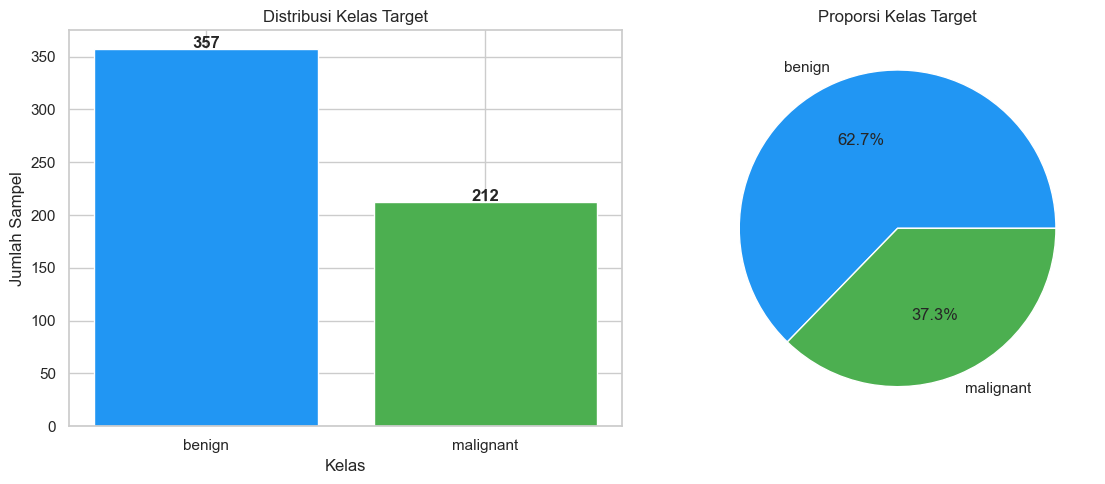

In [5]:
# Distribusi kelas target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#4CAF50'])
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Sampel')
for i, (name, val) in enumerate(counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#4CAF50'])
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

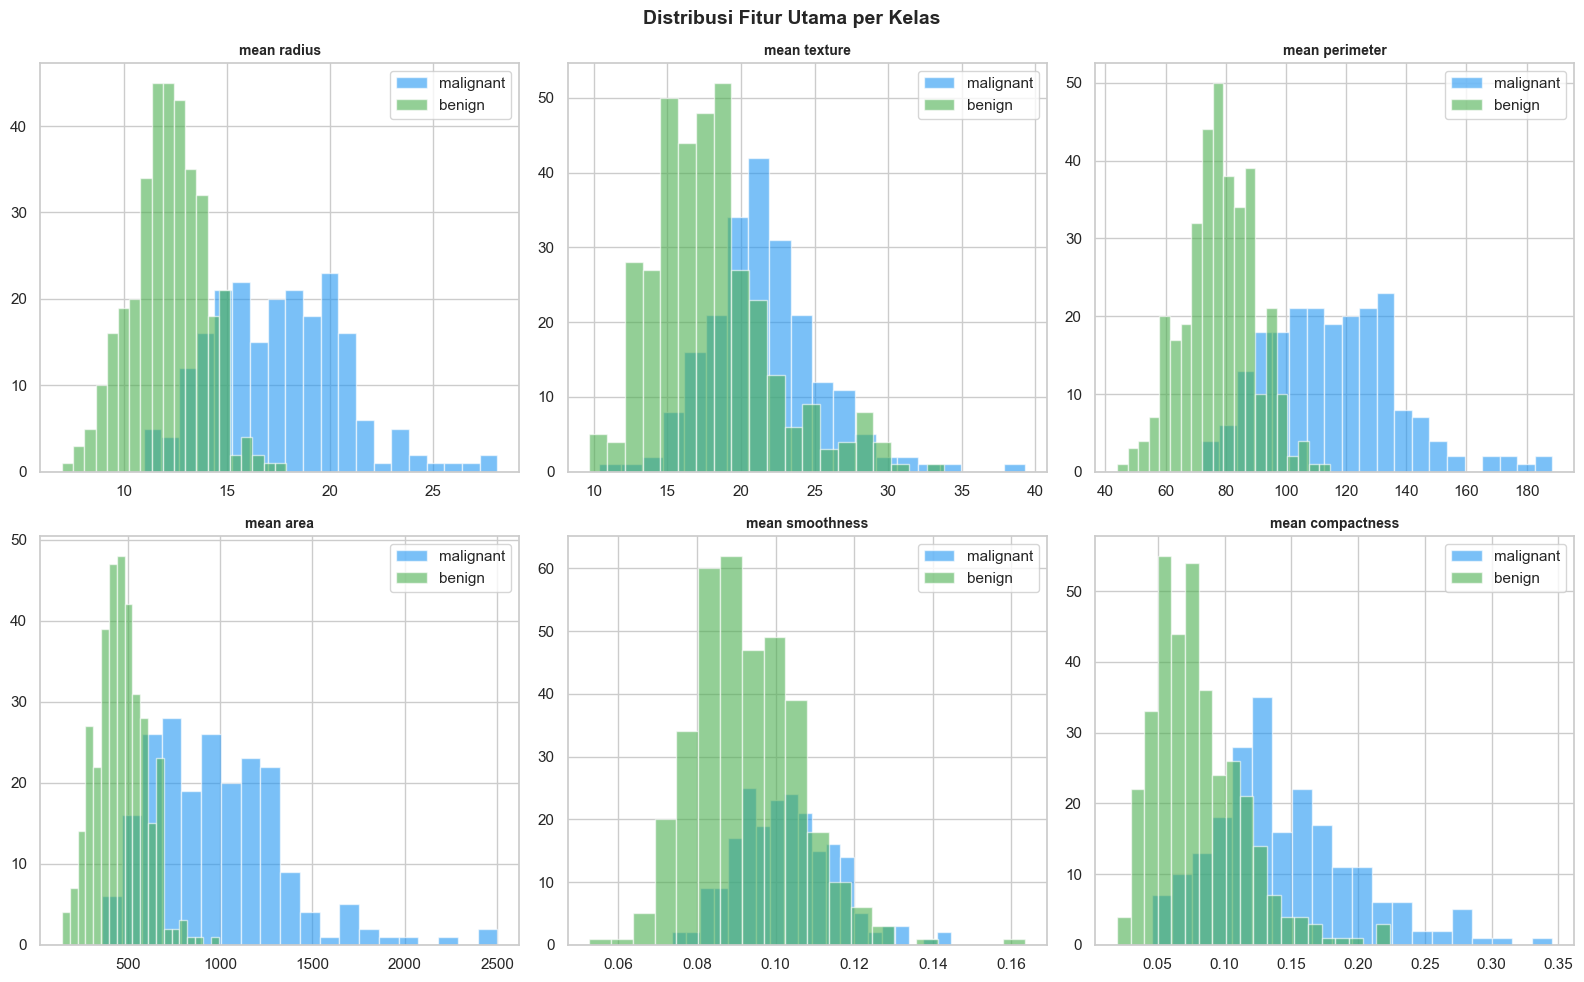

In [6]:
# Distribusi fitur utama per kelas
feature_subset = ['mean radius', 'mean texture', 'mean perimeter',
                  'mean area', 'mean smoothness', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_subset):
    for cls, color in zip(['malignant', 'benign'], ['#2196F3', '#4CAF50']):
        data = df[df['target_name'] == cls][col]
        axes[i].hist(data, bins=20, alpha=0.6, color=color, label=cls)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Utama per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

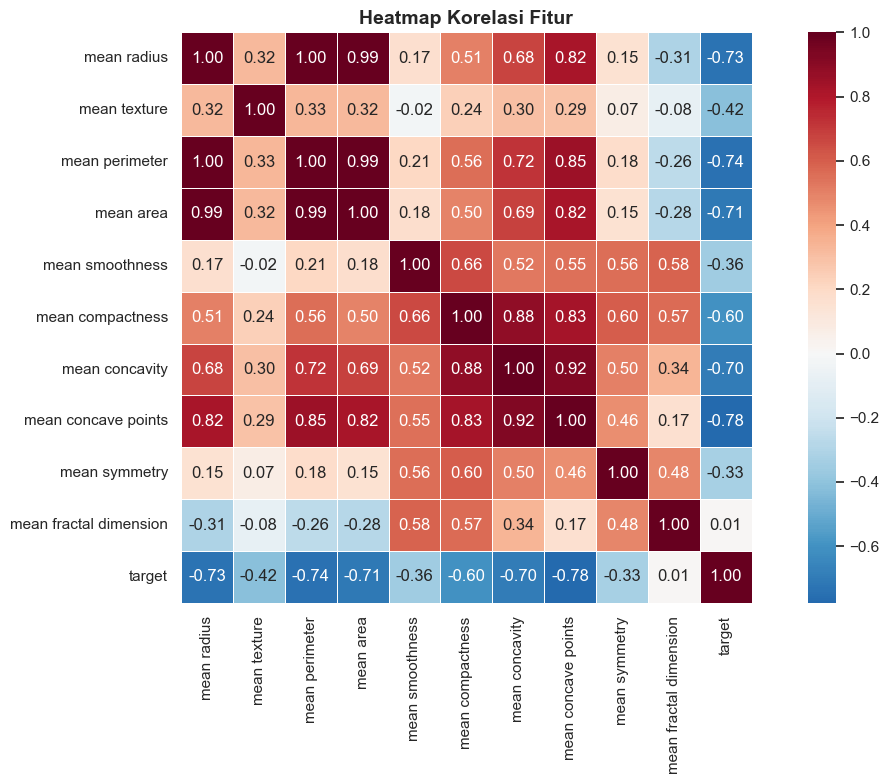

In [7]:
# Heatmap korelasi
feature_cols = [c for c in df.columns if c not in ['target', 'target_name']]
corr = df[feature_cols[:10] + ['target']].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Heatmap Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

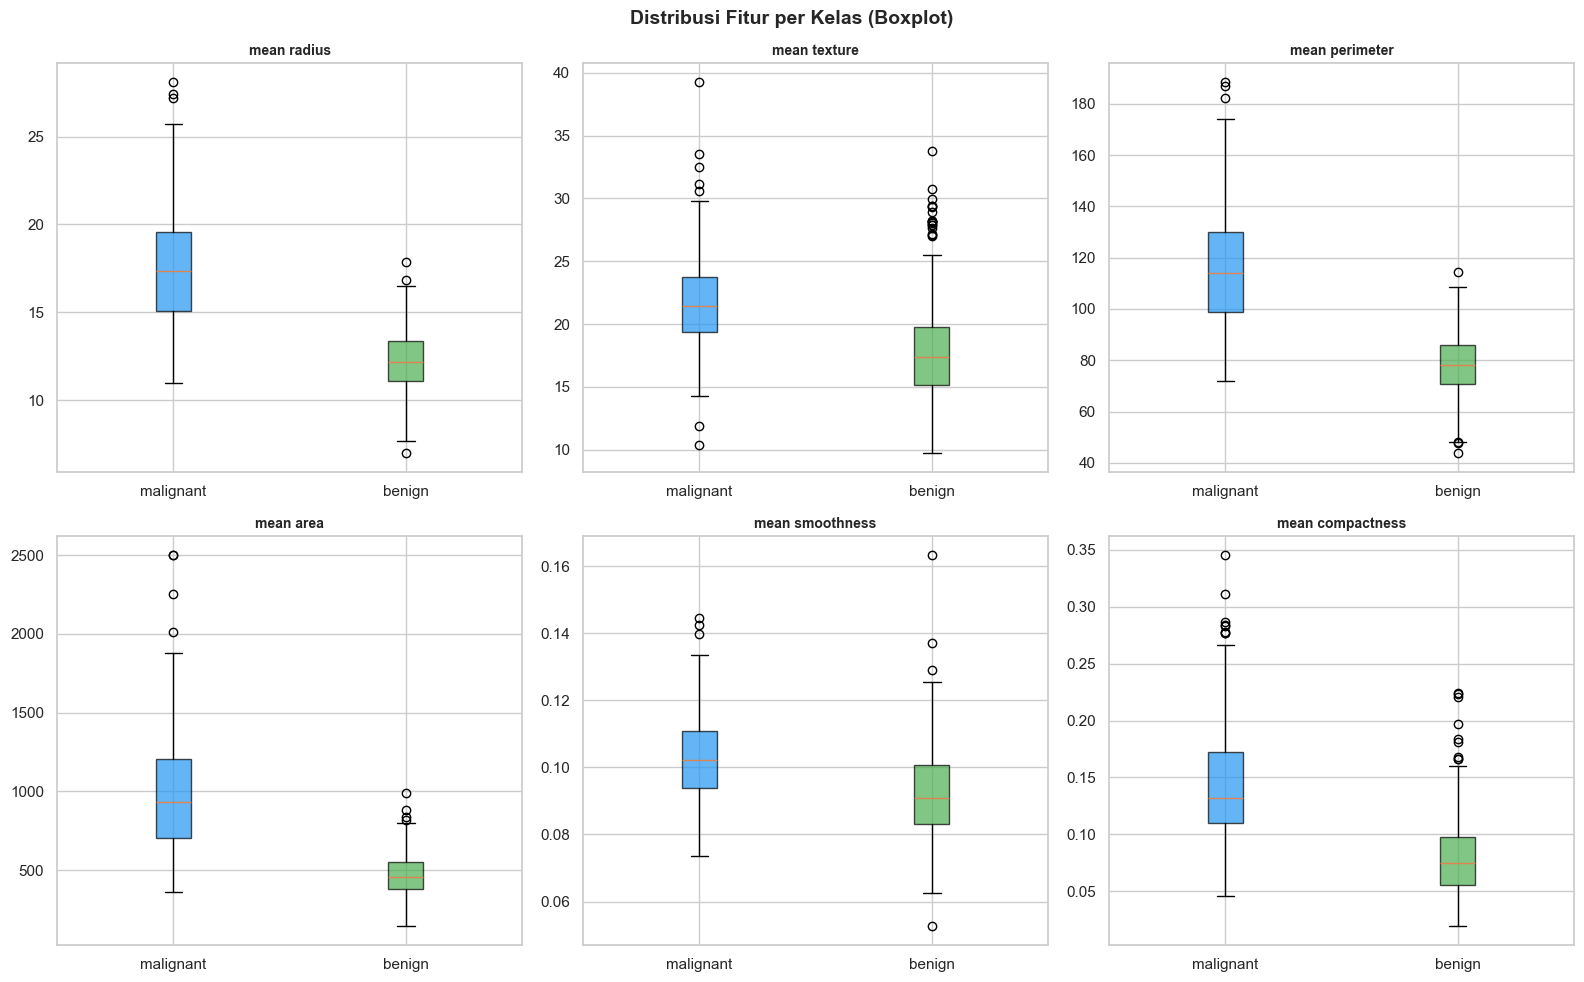

In [8]:
# Boxplot fitur per kelas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_subset):
    data_malignant = df[df['target_name'] == 'malignant'][col].values
    data_benign = df[df['target_name'] == 'benign'][col].values
    bp = axes[i].boxplot([data_malignant, data_benign], patch_artist=True,
                          labels=['malignant', 'benign'])
    for patch, color in zip(bp['boxes'], ['#2196F3', '#4CAF50']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')

plt.suptitle('Distribusi Fitur per Kelas (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_features.png', dpi=120, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini dilakukan preprocessing untuk memastikan kualitas data. Tahapan yang dilakukan:
1. Menangani Missing Values (pengisian dengan nilai median)
2. Deteksi dan Penghapusan Outlier menggunakan Z-Score (threshold = 3.0)
3. Menyimpan dataset hasil preprocessing ke file CSV

In [9]:
# 4.1 Handle missing values
print('Sebelum handling missing values:')
print(f'  Shape: {df.shape}')
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Kolom {col}: diisi dengan median={median_val:.3f}')
if df.isnull().sum().sum() == 0:
    print('  Tidak ada missing values yang ditemukan!')
print(f'Shape setelah handling: {df.shape}')

Sebelum handling missing values:
  Shape: (569, 32)
  Tidak ada missing values yang ditemukan!
Shape setelah handling: (569, 32)


In [10]:
# 4.2 Hapus outlier menggunakan Z-Score (threshold=3.0)
feat_cols = [c for c in numeric_cols if c != 'target']
z_scores = np.abs(stats.zscore(df[feat_cols]))
outlier_mask = (z_scores < 3.0).all(axis=1)
df_preprocessed = df[outlier_mask].reset_index(drop=True)

print(f'Sampel sebelum: {len(df)}')
print(f'Sampel setelah outlier removal: {len(df_preprocessed)}')
print(f'Outlier dihapus: {len(df) - len(df_preprocessed)} sampel')
print(f'Distribusi kelas setelah preprocessing:')
print(df_preprocessed['target_name'].value_counts())

Sampel sebelum: 569
Sampel setelah outlier removal: 495
Outlier dihapus: 74 sampel
Distribusi kelas setelah preprocessing:
target_name
benign       332
malignant    163
Name: count, dtype: int64


In [11]:
# Simpan dataset hasil preprocessing ke CSV
os.makedirs('dataset_preprocessing', exist_ok=True)
df_preprocessed.to_csv(
    'dataset_preprocessing/breast_cancer_preprocessing.csv', index=False)

# Juga simpan di root
df_preprocessed.to_csv('dataset_preprocessing.csv', index=False)

print('Dataset hasil preprocessing berhasil disimpan!')
print(f'Shape: {df_preprocessed.shape}')
print('File: dataset_preprocessing/breast_cancer_preprocessing.csv')
print('File: dataset_preprocessing.csv')

Dataset hasil preprocessing berhasil disimpan!
Shape: (495, 32)
File: dataset_preprocessing/breast_cancer_preprocessing.csv
File: dataset_preprocessing.csv


In [12]:
# Ringkasan akhir
n_orig = len(df)
n_clean = len(df_preprocessed)
print('=' * 50)
print('RINGKASAN PREPROCESSING')
print('=' * 50)
print(f'Dataset asli         : {n_orig} sampel, {df.shape[1]} kolom')
print(f'Setelah preprocessing: {n_clean} sampel, {df_preprocessed.shape[1]} kolom')
print(f'Outlier dihapus      : {n_orig - n_clean} sampel')
classes = df_preprocessed['target_name'].unique().tolist()
print(f'Target classes       : {classes}')
print('=' * 50)
df_preprocessed.head()

RINGKASAN PREPROCESSING
Dataset asli         : 569 sampel, 32 kolom
Setelah preprocessing: 495 sampel, 32 kolom
Outlier dihapus      : 74 sampel
Target classes       : ['malignant', 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
2,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.2,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant
3,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,103.4,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0,malignant
4,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,0.1794,0.05742,...,153.2,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0,malignant
